In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [4]:
print("Models folder:")
print(os.listdir("../models"))

print("\nResults folder:")
print(os.listdir("../results"))

Models folder:
['undersampling_model.pkl', 'baseline_model.pkl', 'class_weight_model.pkl', 'smote_model.pkl']

Results folder:
[]


In [5]:
baseline_model = joblib.load("../models/baseline_model.pkl")
smote_model = joblib.load("../models/smote_model.pkl")
undersampling_model = joblib.load("../models/undersampling_model.pkl")
class_weight_model = joblib.load("../models/class_weight_model.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [6]:
df = pd.read_csv("../data/processed/creditcard_processed.csv")

print("Dataset shape:", df.shape)

Dataset shape: (283726, 31)


In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (226980, 30)
Test set: (56746, 30)


In [9]:
print("Test class distribution:")
print(y_test.value_counts())

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [10]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

In [11]:
def evaluate_model(model, X_test, y_test, threshold=0.5):

    # Get fraud probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Number of alerts
    alerts = int(y_pred.sum())

    return {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR-AUC": pr_auc,
        "Alerts": alerts,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [12]:
baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    threshold=0.5
)

baseline_results

{'Precision': 0.8611111111111112,
 'Recall': 0.6526315789473685,
 'F1': 0.7425149700598802,
 'PR-AUC': 0.6233542486597701,
 'Alerts': 72,
 'TN': np.int64(56641),
 'FP': np.int64(10),
 'FN': np.int64(33),
 'TP': np.int64(62)}

In [13]:
smote_results = evaluate_model(
    smote_model,
    X_test,
    y_test,
    threshold=0.5
)

smote_results

{'Precision': 0.19506172839506172,
 'Recall': 0.8315789473684211,
 'F1': 0.316,
 'PR-AUC': 0.7242381970549283,
 'Alerts': 405,
 'TN': np.int64(56325),
 'FP': np.int64(326),
 'FN': np.int64(16),
 'TP': np.int64(79)}

In [14]:
undersampling_results = evaluate_model(
    undersampling_model,
    X_test,
    y_test,
    threshold=0.5
)

undersampling_results

{'Precision': 0.044252563410685376,
 'Recall': 0.8631578947368421,
 'F1': 0.08418891170431211,
 'PR-AUC': 0.5845976070633283,
 'Alerts': 1853,
 'TN': np.int64(54880),
 'FP': np.int64(1771),
 'FN': np.int64(13),
 'TP': np.int64(82)}

In [15]:
class_weight_results = evaluate_model(
    class_weight_model,
    X_test,
    y_test,
    threshold=0.5
)

class_weight_results

{'Precision': 0.18501170960187355,
 'Recall': 0.8315789473684211,
 'F1': 0.30268199233716475,
 'PR-AUC': 0.700446607762789,
 'Alerts': 427,
 'TN': np.int64(56303),
 'FP': np.int64(348),
 'FN': np.int64(16),
 'TP': np.int64(79)}

In [16]:
comparison = pd.DataFrame([
    {
        "Method": "Baseline",
        **baseline_results
    },
    {
        "Method": "SMOTE",
        **smote_results
    },
    {
        "Method": "Undersampling",
        **undersampling_results
    },
    {
        "Method": "Class Weight",
        **class_weight_results
    }
])

comparison

,Method,Precision,Recall,F1,PR-AUC,Alerts,TN,FP,FN,TP
0,Baseline,0.861111,0.652632,0.742515,0.623354,72,56641,10,33,62
1,SMOTE,0.195062,0.831579,0.316000,0.724238,405,56325,326,16,79
2,Undersampling,0.044253,0.863158,0.084189,0.584598,1853,54880,1771,13,82
3,Class Weight,0.185012,0.831579,0.302682,0.700447,427,56303,348,16,79


In [17]:
tuned_threshold = 0.01

threshold_tuned_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    threshold=tuned_threshold
)

threshold_tuned_results

{'Precision': 0.5163934426229508,
 'Recall': 0.6631578947368421,
 'F1': 0.5806451612903226,
 'PR-AUC': 0.6233542486597701,
 'Alerts': 122,
 'TN': np.int64(56592),
 'FP': np.int64(59),
 'FN': np.int64(32),
 'TP': np.int64(63)}

In [18]:
comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [19]:
best_precision = comparison.loc[
    comparison["Precision"].idxmax()
]

print("Best Precision:")
print(best_precision)

Best Precision:
Method       Baseline
Precision    0.861111
Recall       0.652632
F1           0.742515
PR-AUC       0.623354
Alerts             72
TN              56641
FP                 10
FN                 33
TP                 62
Name: 0, dtype: object


In [20]:
best_recall = comparison.loc[
    comparison["Recall"].idxmax()
]

print("\nBest Recall:")
print(best_recall)


Best Recall:
Method       Undersampling
Precision         0.044253
Recall            0.863158
F1                0.084189
PR-AUC            0.584598
Alerts                1853
TN                   54880
FP                    1771
FN                      13
TP                      82
Name: 2, dtype: object


In [21]:
best_f1 = comparison.loc[
    comparison["F1"].idxmax()
]

print("\nBest F1:")
print(best_f1)


Best F1:
Method       Baseline
Precision    0.861111
Recall       0.652632
F1           0.742515
PR-AUC       0.623354
Alerts             72
TN              56641
FP                 10
FN                 33
TP                 62
Name: 0, dtype: object


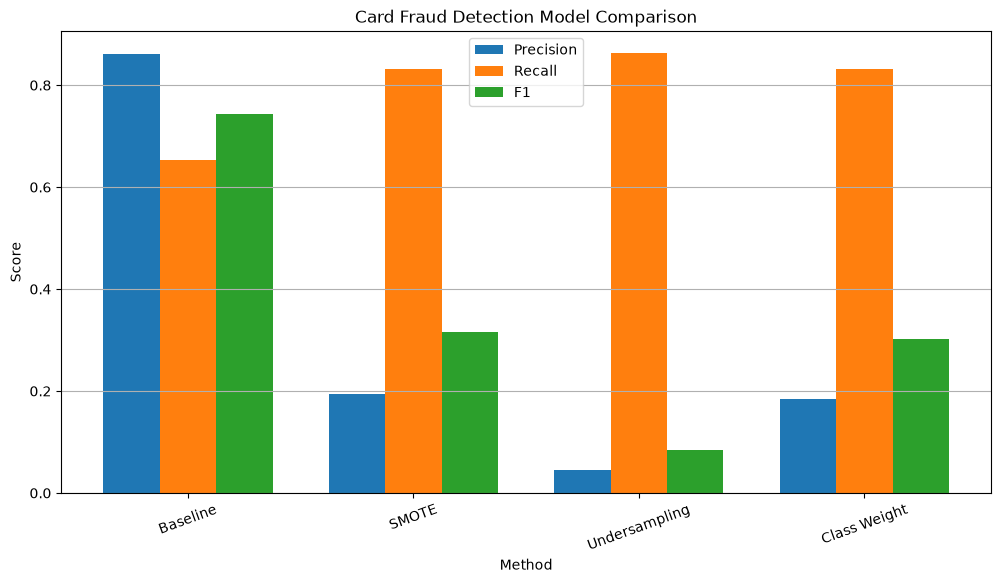

In [ ]:
x = np.arange(len(comparison))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    comparison["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    comparison["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    comparison["F1"],
    width,
    label="F1"
)

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Card Fraud Detection Model Comparison")

plt.xticks(
    x,
    comparison["Method"], # type: ignore
    rotation=20
)

plt.legend()
plt.grid(axis="y")

plt.show()

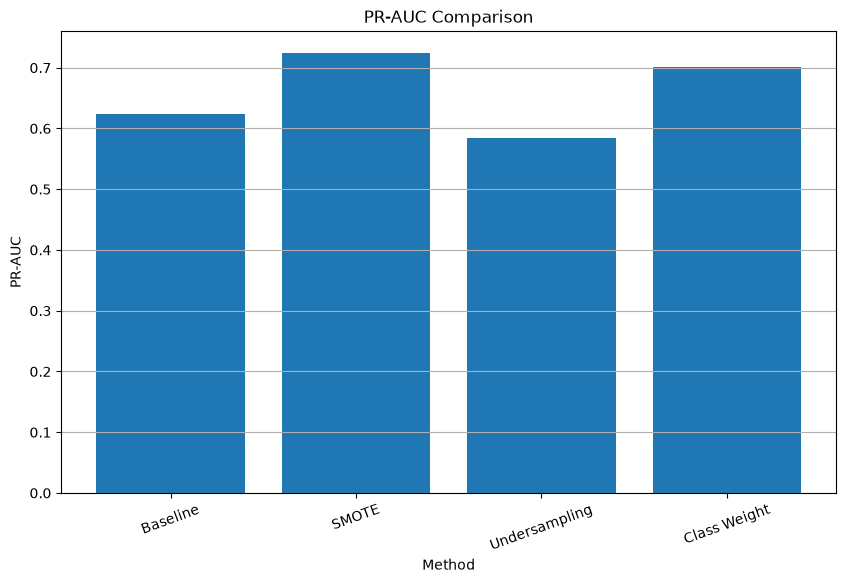

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Method"],
    comparison["PR-AUC"]
)

plt.xlabel("Method")
plt.ylabel("PR-AUC")
plt.title("PR-AUC Comparison")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()